# 01 - Exploration du dataset

Dans cette première étape, nous allons explorer la séquence d’images utilisée dans notre projet. L’objectif est de comprendre la structure du dataset, le nombre d’images, la taille des frames, ainsi que les annotations disponibles comme la bounding box, l’occlusion et la sortie de l’objet du champ de vision.

Nous allons vérifier que les fichiers nécessaires sont bien présents. Nous allons aussi observer quelques images de la séquence pour comprendre le déplacement global de l’objet. Nous interpréterons ensuite ces informations afin de préparer les prochaines étapes du projet.

## 1. Importation des bibliothèques

Nous commençons par importer les bibliothèques nécessaires pour lire les fichiers, charger les images et afficher les résultats.

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Définition des chemins du dataset

Nous définissons les chemins vers le dossier de la séquence et vers les fichiers d’annotations. Cette étape nous permet de vérifier que le dataset est bien organisé avant de commencer l’analyse.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"
full_occlusion_path = dataset_path / "full_occlusion.txt"
out_of_view_path = dataset_path / "out_of_view.txt"

print("Chemin du dataset :", dataset_path)
print("Dossier img existe :", img_path.exists())
print("groundtruth.txt existe :", groundtruth_path.exists())
print("full_occlusion.txt existe :", full_occlusion_path.exists())
print("out_of_view.txt existe :", out_of_view_path.exists())

if not img_path.exists():
    print("Attention : le dossier img est introuvable.")
if not groundtruth_path.exists():
    print("Attention : le fichier groundtruth.txt est introuvable.")
if not full_occlusion_path.exists():
    print("Attention : le fichier full_occlusion.txt est introuvable.")
if not out_of_view_path.exists():
    print("Attention : le fichier out_of_view.txt est introuvable.")

Chemin du dataset : ..\data\car\car-11
Dossier img existe : True
groundtruth.txt existe : True
full_occlusion.txt existe : True
out_of_view.txt existe : True


## 3. Chargement et vérification des images

Nous allons maintenant lister les images disponibles dans le dossier `img`. Nous ne chargeons pas toutes les images en mémoire : nous gardons seulement leurs chemins pour travailler proprement.

In [3]:
image_extensions = [".jpg", ".jpeg", ".png"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []

print("Nombre total d'images :", len(image_files))
print("Cinq premiers noms d'images :")
for image_file in image_files[:5]:
    print("-", image_file.name)

first_image = None
image_height = None
image_width = None
image_channels = None

if len(image_files) > 0:
    first_image = cv2.imread(str(image_files[0]))

    if first_image is not None:
        image_height, image_width = first_image.shape[:2]
        image_channels = 1 if len(first_image.shape) == 2 else first_image.shape[2]
        print("Taille de la première image :")
        print("- Hauteur :", image_height)
        print("- Largeur :", image_width)
        print("- Nombre de canaux :", image_channels)
    else:
        print("La première image n'a pas pu être chargée avec OpenCV.")
else:
    print("Aucune image n'a été trouvée dans le dossier img.")

Nombre total d'images : 1661
Cinq premiers noms d'images :
- 00000001.jpg
- 00000002.jpg
- 00000003.jpg
- 00000004.jpg
- 00000005.jpg
Taille de la première image :
- Hauteur : 720
- Largeur : 1280
- Nombre de canaux : 3


## 4. Affichage de quelques frames de la séquence

Nous affichons cinq frames réparties dans la séquence : la première, environ 25%, 50%, 75% et la dernière. Cela nous permet d’observer visuellement le contenu de la séquence.

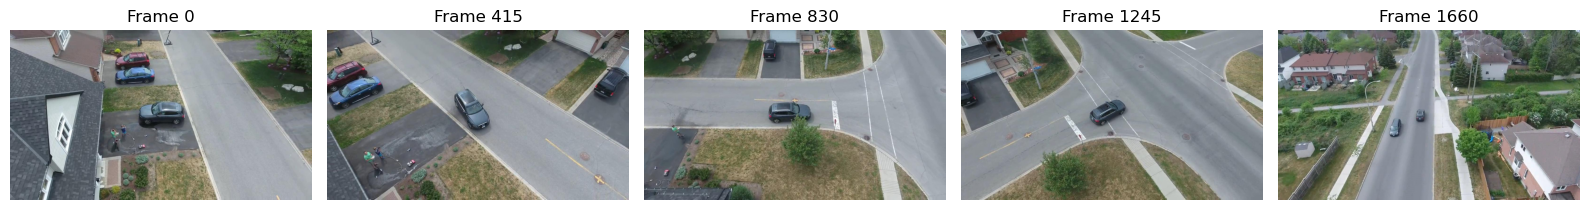

In [4]:
if len(image_files) > 0:
    frame_indices = [0, len(image_files) // 4, len(image_files) // 2, 3 * len(image_files) // 4, len(image_files) - 1]
    frame_indices = sorted(set(frame_indices))

    fig, axes = plt.subplots(1, len(frame_indices), figsize=(16, 4))
    if len(frame_indices) == 1:
        axes = [axes]

    for axis, index in zip(axes, frame_indices):
        image = cv2.imread(str(image_files[index]))

        if image is not None:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            axis.imshow(image_rgb)
            axis.set_title(f"Frame {index}")
        else:
            axis.set_title(f"Frame {index} non chargée")

        axis.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible d'afficher les frames car aucune image n'a été trouvée.")

Cette visualisation nous permet d’observer le déplacement global de l’objet dans la séquence et de vérifier si l’objet reste visible dans les images sélectionnées.

## 5. Lecture du fichier groundtruth.txt

Nous lisons maintenant le fichier `groundtruth.txt`. Ce fichier contient la bounding box de l’objet pour chaque frame : `x`, `y`, `largeur` et `hauteur`.

In [5]:
groundtruth = pd.DataFrame(columns=["x", "y", "w", "h"])

if groundtruth_path.exists() and groundtruth_path.stat().st_size > 0:
    groundtruth = pd.read_csv(
        groundtruth_path,
        header=None,
        sep=r"[,\s]+",
        engine="python"
    )

    groundtruth = groundtruth.iloc[:, :4]
    groundtruth.columns = ["x", "y", "w", "h"]

    display(groundtruth.head())
    print("Dimensions du DataFrame :", groundtruth.shape)

    if len(groundtruth) == len(image_files):
        print("Le nombre de lignes du groundtruth correspond au nombre d'images.")
    else:
        print("Attention : le nombre de lignes du groundtruth ne correspond pas au nombre d'images.")
        print("Nombre de lignes groundtruth :", len(groundtruth))
        print("Nombre d'images :", len(image_files))
else:
    print("Le fichier groundtruth.txt est vide ou introuvable.")

,x,y,w,h
0,543,305,202,91
1,544,301,199,90
2,544,301,197,89
3,544,300,196,91
4,543,302,197,89


Dimensions du DataFrame : (1661, 4)
Le nombre de lignes du groundtruth correspond au nombre d'images.


Le fichier groundtruth contient la position de l’objet dans chaque image. Ces informations seront utilisées principalement pour initialiser l’objet à suivre et pour comparer visuellement nos résultats.

## 6. Visualisation de la bounding box initiale

Nous allons vérifier la première annotation en dessinant la bounding box initiale sur la première image de la séquence.

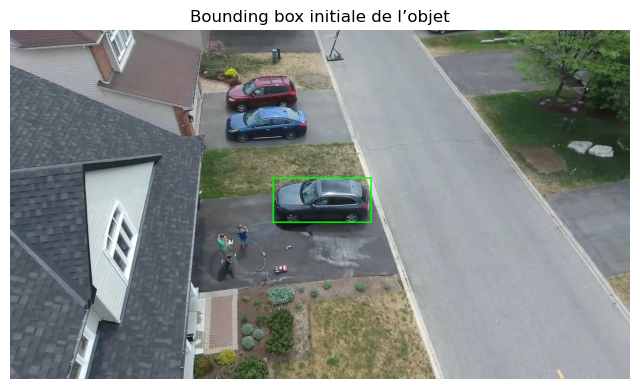

In [6]:
if len(image_files) > 0 and len(groundtruth) > 0:
    image = cv2.imread(str(image_files[0]))

    if image is not None:
        x, y, w, h = groundtruth.iloc[0].astype(int)
        image_with_bbox = image.copy()
        cv2.rectangle(image_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

        image_rgb = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 5))
        plt.imshow(image_rgb)
        plt.title("Bounding box initiale de l’objet")
        plt.axis("off")
        plt.show()
    else:
        print("La première image n'a pas pu être chargée.")
else:
    print("Impossible d'afficher la bounding box initiale.")

Cette étape permet de vérifier que l’annotation initiale correspond bien à l’objet étudié. Dans notre projet, cette bounding box servira à initialiser la région d’intérêt de l’objet.

## 7. Visualisation de plusieurs bounding boxes dans la séquence

Nous affichons maintenant plusieurs images réparties dans la séquence avec leur bounding box. Cette observation reste descriptive : nous ne faisons pas encore de suivi automatique.

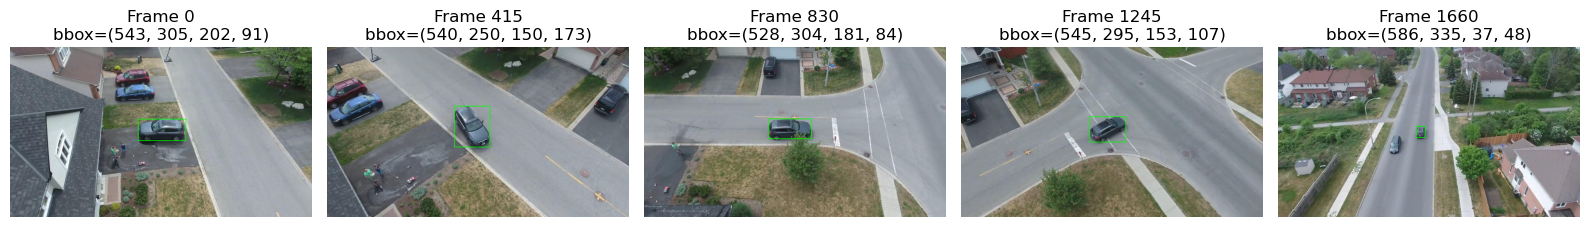

In [7]:
number_of_valid_frames = min(len(image_files), len(groundtruth))

if number_of_valid_frames > 0:
    bbox_indices = [0, number_of_valid_frames // 4, number_of_valid_frames // 2, 3 * number_of_valid_frames // 4, number_of_valid_frames - 1]
    bbox_indices = sorted(set(bbox_indices))

    fig, axes = plt.subplots(1, len(bbox_indices), figsize=(16, 4))
    if len(bbox_indices) == 1:
        axes = [axes]

    for axis, index in zip(axes, bbox_indices):
        image = cv2.imread(str(image_files[index]))

        if image is not None:
            x, y, w, h = groundtruth.iloc[index].astype(int)
            image_with_bbox = image.copy()
            cv2.rectangle(image_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

            image_rgb = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)
            axis.imshow(image_rgb)
            axis.set_title(f"Frame {index}\nbbox=({x}, {y}, {w}, {h})")
        else:
            axis.set_title(f"Frame {index} non chargée")

        axis.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible d'afficher les bounding boxes car les images ou le groundtruth manquent.")

Cette visualisation permet de suivre approximativement l’évolution de la position de l’objet dans la séquence. Elle nous donne une première idée de la trajectoire avant d’appliquer l’estimation de mouvement.

## 8. Lecture des fichiers full_occlusion et out_of_view

Nous vérifions maintenant les fichiers qui indiquent si l’objet est totalement occulté ou s’il sort du champ de vision. Ces informations nous aideront à interpréter les difficultés possibles dans les prochaines étapes.

In [8]:
def read_flag_file(file_path, file_name):
    """Lire un fichier contenant des valeurs 0/1 par frame."""
    if not file_path.exists():
        print(file_name, ": fichier introuvable.")
        return np.array([])

    if file_path.stat().st_size == 0:
        print(file_name, ": fichier vide.")
        return np.array([])

    values = pd.read_csv(file_path, header=None, sep=r"[,\s]+", engine="python")
    values = values.values.flatten()
    values = pd.to_numeric(pd.Series(values), errors="coerce").fillna(0).astype(int).to_numpy()

    return values


full_occlusion = read_flag_file(full_occlusion_path, "full_occlusion.txt")
out_of_view = read_flag_file(out_of_view_path, "out_of_view.txt")

full_occlusion_indices = np.where(full_occlusion == 1)[0].tolist()
out_of_view_indices = np.where(out_of_view == 1)[0].tolist()

print("Nombre de frames en occlusion complète :", len(full_occlusion_indices))
if len(full_occlusion_indices) > 0:
    print("Indices concernés :", full_occlusion_indices)
else:
    print("Aucune frame en occlusion complète n'a été détectée.")

print("Nombre de frames hors du champ :", len(out_of_view_indices))
if len(out_of_view_indices) > 0:
    print("Indices concernés :", out_of_view_indices)
else:
    print("Aucune frame hors du champ n'a été détectée.")

Nombre de frames en occlusion complète : 0
Aucune frame en occlusion complète n'a été détectée.
Nombre de frames hors du champ : 0
Aucune frame hors du champ n'a été détectée.


Ces informations sont importantes car l’occlusion ou la sortie du champ peuvent perturber le suivi de l’objet. Si ces cas existent, nous devrons les prendre en compte dans les prochaines étapes.

## 9. Première conclusion de l’exploration

Nous terminons cette première étape par un résumé simple des informations observées. Cette conclusion nous aide à préparer la suite du projet de manière claire.

In [9]:
groundtruth_status = "disponible" if len(groundtruth) > 0 else "non disponible"
image_size = "non déterminée"

if image_height is not None and image_width is not None:
    image_size = f"{image_height} x {image_width} pixels"

if len(full_occlusion_indices) > 0:
    occlusion_status = f"présence d'occlusions complètes sur {len(full_occlusion_indices)} frame(s)"
else:
    occlusion_status = "absence d'occlusion complète détectée"

if len(out_of_view_indices) > 0:
    out_of_view_status = f"présence de sorties du champ sur {len(out_of_view_indices)} frame(s)"
else:
    out_of_view_status = "absence de sortie du champ détectée"

print("Conclusion de l'exploration")
print("-")
print(f"Nous avons vérifié que la séquence contient {len(image_files)} image(s).")
print(f"Nous observons que la taille des images est : {image_size}.")
print(f"Le fichier groundtruth est {groundtruth_status}.")
print(f"Nous observons une {occlusion_status}.")
print(f"Nous observons une {out_of_view_status}.")
print("À la fin de cette exploration, nous avons vérifié que la séquence contient les images nécessaires ainsi que les annotations de l’objet.")
print("La bounding box initiale permettra de définir la région d’intérêt, et les prochaines étapes consisteront à prétraiter les images avant d’appliquer la méthode de Lucas-Kanade.")

Conclusion de l'exploration
-
Nous avons vérifié que la séquence contient 1661 image(s).
Nous observons que la taille des images est : 720 x 1280 pixels.
Le fichier groundtruth est disponible.
Nous observons une absence d'occlusion complète détectée.
Nous observons une absence de sortie du champ détectée.
À la fin de cette exploration, nous avons vérifié que la séquence contient les images nécessaires ainsi que les annotations de l’objet.
La bounding box initiale permettra de définir la région d’intérêt, et les prochaines étapes consisteront à prétraiter les images avant d’appliquer la méthode de Lucas-Kanade.
